In [13]:
import json
from pathlib import Path
import h5py
import numpy as np
import matplotlib.pyplot as plt
import os
import sys
from os import path
sys.path.insert(0, "/home/thomasb")
from albatros_analysis.src.correlations import timing_solution_class as tsc
import importlib
importlib.reload(tsc)

<module 'albatros_analysis.src.correlations.timing_solution_class' from '/home/thomasb/albatros_analysis/src/correlations/timing_solution_class.py'>

# Typical Use

This is usually how you would use the TimingSolution object

In [14]:
# directory where all solutions live
root_dir = '/scratch/thomasb/timing_solution'

# to see what batches have solutions, run this
batches = tsc.get_all_batches(root_dir)
print(batches)

[(1753132820, 1753200010), (1753200150, 1753286410)]


In [ ]:
unix_query = 1753210000

# initialize the object using the query time and data directory
tsobj = tsc.TimingSolution(unix_query, root_dir)

In [6]:
# plenty of properties you can check, including:
print('name of batch', tsobj.batch_name)
print('batch start time', tsobj.batch_start_unix)
print('batch end time', tsobj.batch_end_unix)
print('reference antenna for batch', tsobj.ref_ant)
print('non-ref antenna for batch', tsobj.non_ref_ants)
print('UTC to ref ant spectra conversion', tsobj.UTC_per_spec)

name of batch batch_1753200150
batch start time 1753200150
batch end time 1753286410
reference antenna for batch MARS1
non-ref antenna for batch ['MARS2', 'MARS4', 'MARS5', 'MARS6', 'MARS7', 'MARS8']
UTC to ref ant spectra conversion 1.638402806904218e-05


In [8]:
# also has the raw data as a property
print('taus shape', tsobj.taus.shape)
print('spectra shape', tsobj.spectra.shape)
print('unix shape', tsobj.unix.shape)

taus shape (6, 1560)
spectra shape (1560,)
unix shape (1560,)


number of baselines (containing ref ant) in tau data: 6
number of desired interpolation unix times: 100000
number of data unix times (1560,)
shape of all tau values (6, 100000)


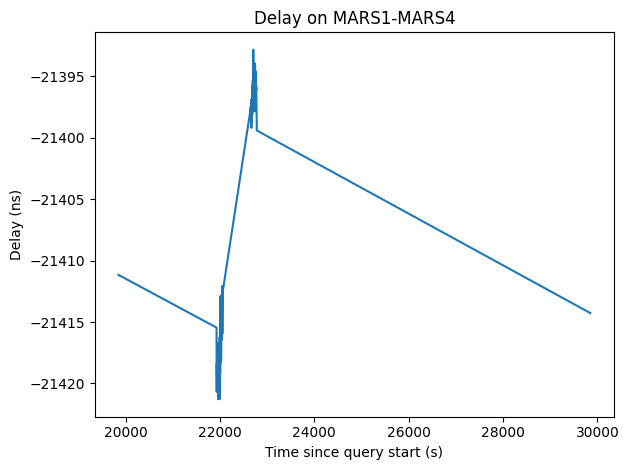

In [13]:
# can easily interpolate between any two points WITHIN the batch
interp_start, interp_end = 1753220000, 1753230000
dt = 0.1 # seconds
unix_interp, taus_interp = tsobj.interpolate_delay(interp_start, interp_end, dt)

#pick and baseline index and plot what it looks like
bline_idx = 1
print('shape of all tau values', taus_interp.shape)
plt.plot(unix_interp - tsobj.batch_start_unix, taus_interp[bline_idx,:])
plt.xlabel('Time since query start (s)')
plt.ylabel(f'Delay (ns)')
plt.title(f'Delay on {tsobj.ref_ant}-{tsobj.non_ref_ants[bline_idx]}')
plt.tight_layout()

# TESTING AREA

In [ ]:
# SOME TESTS TO ADD

# check it goes to the right baseline

# check it goes in the right order: correct pulse and all that

# implementation test: compare between the debug timing sol version and the TimingSolution found versions

# Generate some fake data

We're going to run some fake data with some easy numbers. Will run various tests on this same data.

For simplicity we'll say a spectrum is about 0.1 seconds, so in 1000 seconds there are 10k spectra

In [178]:
path_test = '/scratch/thomasb/timing_solution_testing'
os.makedirs(path_test, exist_ok=True)

path_index = os.path.join(path_test, 'index.json')

In [179]:
batch_start1 = 1000
batch_end1 = 1800
UTC_per_spec1 = 0.1
UTC_offset1 = 1000

batch_start2 = 2000
batch_end2 = 2900
UTC_per_spec2 = 0.1
UTC_offset2 = 1000

batch_start3 = 3000
batch_end3 = 3600
UTC_per_spec3 = 0.1
UTC_offset3 = 1000

In [180]:
index = [
    {
        "batch": f"batch_{batch_start1}",
        "start": batch_start1,
        "end": batch_end1,
        "ref_ant": "MARS1",
        "non_ref_ants": ["MARS2", "MARS3"],
        "UTC_per_spec":  UTC_per_spec1,
        "UTC_offset":  UTC_offset1
    },
    {
        "batch": f"batch_{batch_start2}",
        "start": batch_start2,
        "end": batch_end2,
        "ref_ant": "MARS2",
        "non_ref_ants": ["MARS1", "MARS3"],
        "UTC_per_spec":  UTC_per_spec2,
        "UTC_offset":  UTC_offset2
    },
    {
        "batch": f"batch_{batch_start3}",
        "start": batch_start3,
        "end": batch_end3,
        "ref_ant": "MARS3",
        "non_ref_ants": ["MARS1", "MARS2"],
        "UTC_per_spec":  UTC_per_spec3,
        "UTC_offset":  UTC_offset3
    }
]

with open(path_index, 'w') as f:
    json.dump(index, f, indent=4)

In [287]:
def tau_generator(spectra, nbl, deg=1):
    taus = np.zeros((nbl, len(spectra)))

    for bl in range(nbl):
        taus[bl, :] = (
            (bl + 1) * (spectra/100)**2
            + bl * spectra
            + 10*bl
        )

    return taus

In [288]:
spectra_template = np.array([100, 150, 200, 250, 300, 350, 400, 
                            1000, 1050, 1100, 1150, 1200, 1250, 1300, 1350, 1400, 1450, 1500, 
                            4200, 4250, 4300, 4350, 
                            5600, 5650, 5700, 5750, 5800])

In [289]:
spectra1 = spectra_template
taus1    = tau_generator(spectra1, 2, deg=1)
utcs1 = spectra1*UTC_per_spec1 + UTC_offset1

with h5py.File(os.path.join(path_test, f'batch_{batch_start1}.h5'), "w") as f:
        f.create_dataset("spectra", data=spectra1)
        f.create_dataset("taus", data=taus1)

spectra2 = spectra_template + 10000
taus2    = tau_generator(spectra2, 2, deg=2)
utcs2 = spectra2*UTC_per_spec2 + UTC_offset2

with h5py.File(os.path.join(path_test, f'batch_{batch_start2}.h5'), "w") as f:
        f.create_dataset("spectra", data=spectra2)
        f.create_dataset("taus", data=taus2)

spectra3 = spectra_template + 20000
taus3    = tau_generator(spectra3, 2, deg=3)
utcs3 = spectra3*UTC_per_spec3 + UTC_offset3

with h5py.File(os.path.join(path_test, f'batch_{batch_start3}.h5'), "w") as f:
        f.create_dataset("spectra", data=spectra3)
        f.create_dataset("taus", data=taus3)

In [290]:
print(utcs1)
print(utcs2)
print(utcs3)

[1010. 1015. 1020. 1025. 1030. 1035. 1040. 1100. 1105. 1110. 1115. 1120.
 1125. 1130. 1135. 1140. 1145. 1150. 1420. 1425. 1430. 1435. 1560. 1565.
 1570. 1575. 1580.]
[2010. 2015. 2020. 2025. 2030. 2035. 2040. 2100. 2105. 2110. 2115. 2120.
 2125. 2130. 2135. 2140. 2145. 2150. 2420. 2425. 2430. 2435. 2560. 2565.
 2570. 2575. 2580.]
[3010. 3015. 3020. 3025. 3030. 3035. 3040. 3100. 3105. 3110. 3115. 3120.
 3125. 3130. 3135. 3140. 3145. 3150. 3420. 3425. 3430. 3435. 3560. 3565.
 3570. 3575. 3580.]


# Batch Test

Make sure it only accepts time intervals that are within one batch.

In [291]:
importlib.reload(tsc)

<module 'albatros_analysis.src.correlations.timing_solution_class' from '/home/thomasb/albatros_analysis/src/correlations/timing_solution_class.py'>

In [292]:
obj = tsc.TimingSolution(path_test)

In [293]:
#expect it to work fine
_, _ = obj.find_timing_sol(1200, 1600, 0.1, extrapolate = True)

Your data lives in batch_1000
number of baselines in tau data: 2
number of queried unix times: 4000
number of data unix times (27,)


In [294]:
#expect it to work fine
_, _ = obj.find_timing_sol(1000, 1800, 0.1, extrapolate = True)

Your data lives in batch_1000
number of baselines in tau data: 2
number of queried unix times: 8000
number of data unix times (27,)


In [295]:
#expect it to break (no times before)
try:
    _, _ = obj.find_timing_sol(999, 1600, 0.1, extrapolate = True)
except ValueError as e:
    print(e)

You are asking for times that are not contained in a single batch.


In [296]:
#expect it to break (no times after)
try:
    _, _ = obj.find_timing_sol(2000, 2901, 0.1, extrapolate = True)
except ValueError as e:
    print(e)

You are asking for times that are not contained in a single batch.


# Extrapolation Check

Want to see if it triggers the extrapolation warning if the requested timestamps are outside the passes for some batch

In [297]:
#expect it to work fine
_, _ = obj.find_timing_sol(1200, 1500, 0.1, extrapolate = False)

Your data lives in batch_1000
number of baselines in tau data: 2
number of queried unix times: 3000
number of data unix times (27,)


In [298]:
#expect it to work fine (right on the line)
_, _ = obj.find_timing_sol(2010, 2580, 0.1, extrapolate = False)

Your data lives in batch_2000
number of baselines in tau data: 2
number of queried unix times: 5700
number of data unix times (27,)


In [299]:
#expect it to break (data outsidet the sats, late)
try:
    _, _ = obj.find_timing_sol(1200, 1600, 0.1, extrapolate = False)
except ValueError as e:
    print(e)

Your data lives in batch_1000
Requested times outside batch range. Don't want to extrapolate.


In [300]:
#expect it to break (data outsidet the sats, early)
try:
    _, _ = obj.find_timing_sol(2005, 2400, 0.1, extrapolate = False)
except ValueError as e:
    print(e)

Your data lives in batch_2000
Requested times outside batch range. Don't want to extrapolate.


# Interpolation Check

In [301]:
t1, t2, tres = 1000, 1800, 0.1

utcs_found, taus_found = obj.find_timing_sol(t1, t2, tres)

utcs_calc = np.arange(t1, t2, tres)
utcs_data = spectra1*UTC_per_spec1 + UTC_offset1
taus_calc = np.zeros((2, len(utcs_calc)))
for i in range(2):
    taus_calc[i,:] = np.interp(utcs_calc, utcs_data, taus1[i,:])

Your data lives in batch_1000
number of baselines in tau data: 2
number of queried unix times: 8000
number of data unix times (27,)


Max absolute residual: 0.0


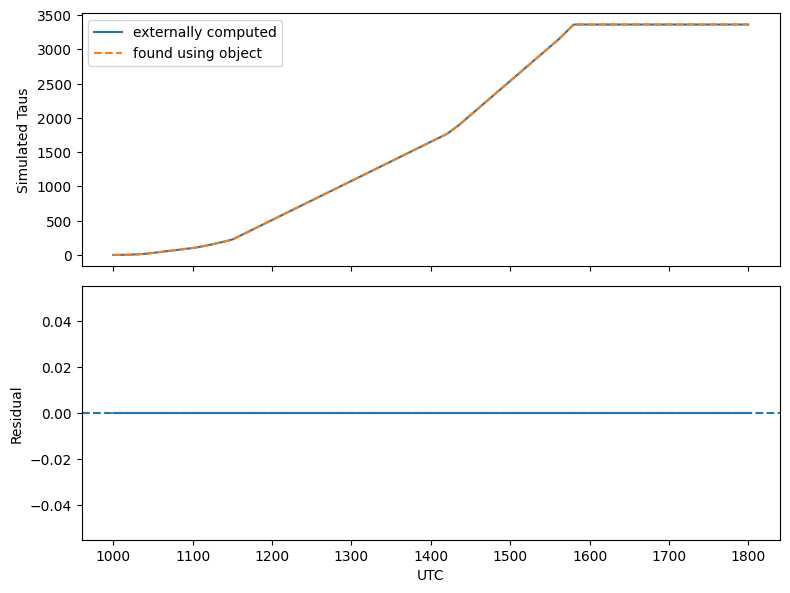

In [302]:
bl_idx = 0

residuals = taus_calc[bl_idx, :] - taus_found[bl_idx, :]

print("Max absolute residual:", np.max(np.abs(residuals)))

fig, ax = plt.subplots(2, 1, figsize=(8, 6), sharex=True)

# Values
ax[0].plot(utcs_calc, taus_calc[bl_idx, :], label='externally computed')
ax[0].plot(utcs_found, taus_found[bl_idx, :], '--', label='found using object')
ax[0].set_ylabel('Simulated Taus')
ax[0].legend()

# Residuals
ax[1].plot(utcs_calc, residuals)
ax[1].axhline(0, linestyle='--')
ax[1].set_xlabel('UTC')
ax[1].set_ylabel('Residual')

plt.tight_layout()
plt.show()

# Baseline Check

Want to make sure the correct data is assigned to the correct baseline, checking the map and such